## Cat & Dog Classification using CNN

In [1]:
#Implementation libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense 
from tensorflow.keras.layers import Conv2D, MaxPooling2D 
from tensorflow.keras.utils import image_dataset_from_directory 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img 
from tensorflow.keras.preprocessing import image_dataset_from_directory 

import os 
import matplotlib.image as mpimg

In [2]:
# Importing Dataset  
# The ZipFile module extracts dataset files from the zip archive. 
# Extracted data is stored in the 'dog-vs-cat-classification' folder.
from zipfile import ZipFile
data_path = 'dog-vs-cat.zip'
with ZipFile(data_path, 'r') as zip:
    zip.extractall()
    print('the data set has been extracted')

the data set has been extracted


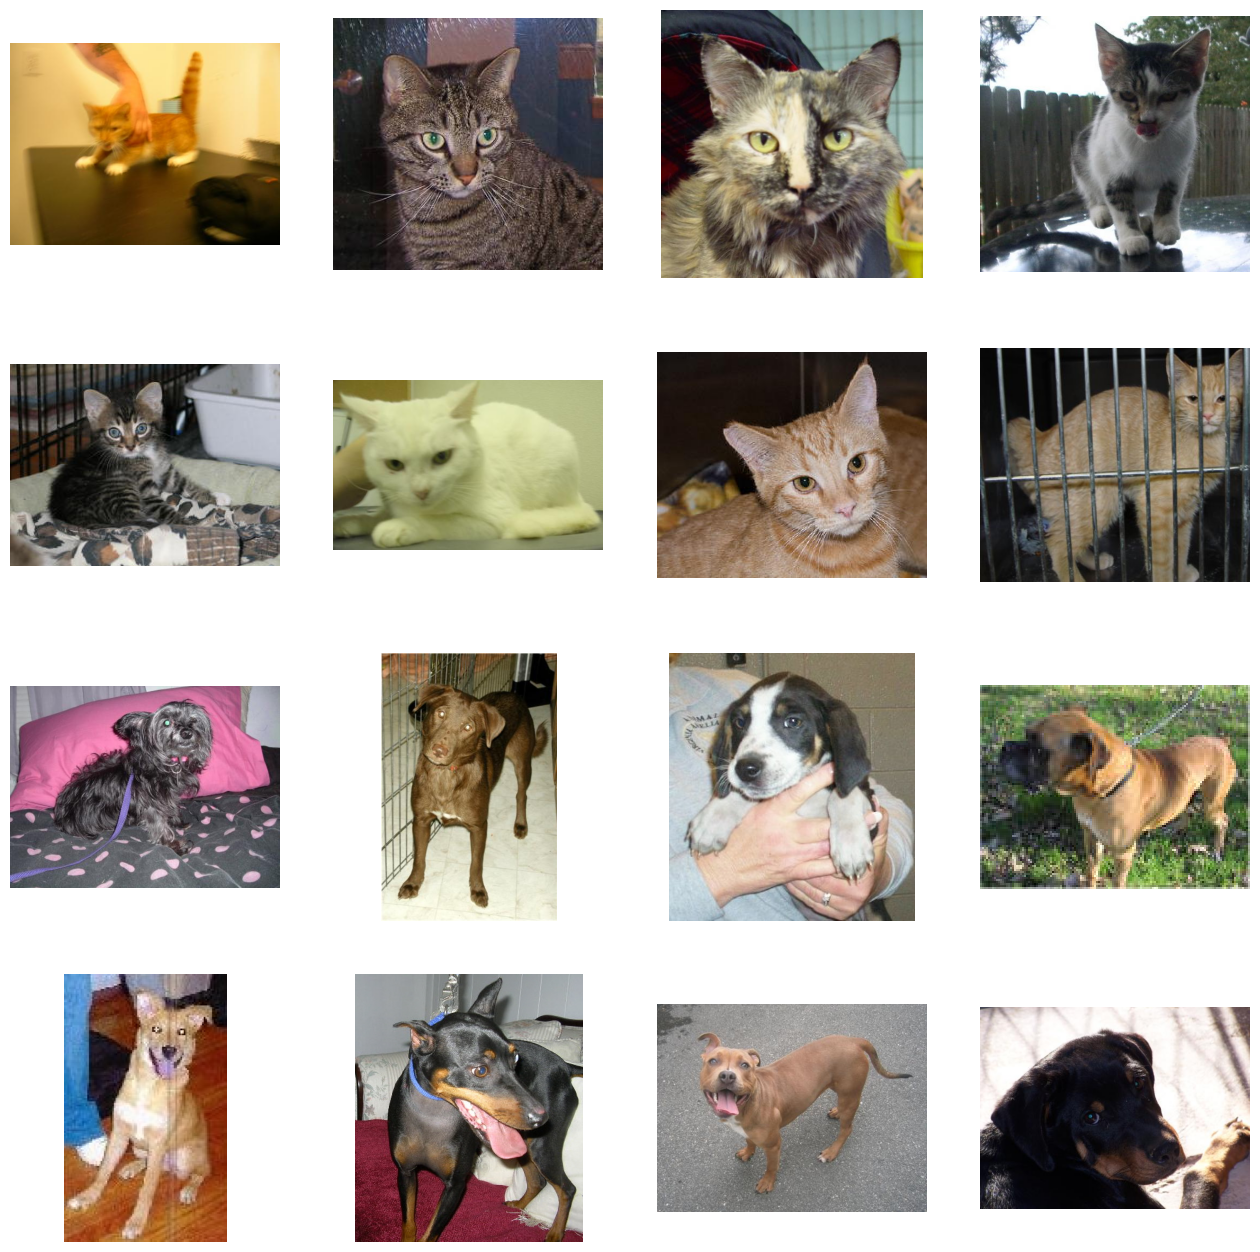

In [3]:
# Visualizating the Data 
# We extract image paths and loads them using Matplotlib and plot grid visualization using subplot(). 
# • fig = plt.gcf() gets the current figure. 
# • fig.set_size_inches(16, 16) sets the figure size. 
# • cat_dir and dog_dir define paths to the cat and dog image directories. 
# • cat_names and dog_names list the image files in each directory. 
# • cat_images and dog_images select images based on pic_index. 
# • plt.subplot(4, 4, i+1) creates a 4x4 grid for images. 
# • sp.axis('Off') hides the axis. 
# • mpimg.imread(img_path) reads each image and plt.imshow(img) displays it. 
# • plt.show() shows the grid of images. 

import os 
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg 
plt.figure(figsize=(16, 16)) 
cat_dir = os.path.join('dog-vs-cat/cat') 
dog_dir = os.path.join('dog-vs-cat/dog') 
cat_names = os.listdir(cat_dir) 
dog_names = os.listdir(dog_dir) 
pic_index = 8  # safe value 
cat_images = [os.path.join(cat_dir, fname)  
              for fname in cat_names[pic_index-8:pic_index]] 
dog_images = [os.path.join(dog_dir, fname)  
              for fname in dog_names[pic_index-8:pic_index]] 
for i, img_path in enumerate(cat_images + dog_images): 
    sp = plt.subplot(4, 4, i+1) 
 
 
    sp.axis('Off') 
    img = mpimg.imread(img_path) 
    plt.imshow(img) 
plt.show()

In [4]:
#Splitting Dataset 
# We split the dataset into training and validation sets. 
# • image_dataset_from_directory: is used for data augmentation and scaling images. 
# • The dataset is split into 90% training and 10% validation. 
# • target_size=(200, 200): Resizes images to 200x200 pixels. 
# • batch_size=32: Defines the number of images per batch.

base_dir = 'dog-vs-cat' 
train_datagen = image_dataset_from_directory(base_dir, 
                                                  image_size=(200,200), 
                                                  subset='training', 
                                                  seed = 1, 
                                                 validation_split=0.1, 
                                                  batch_size= 32) 
test_datagen = image_dataset_from_directory(base_dir, 
                                                  image_size=(200,200), 
                                                  subset='validation', 
                                                  seed = 1, 
                                                 validation_split=0.1, 
                                                  batch_size= 32)

Found 102 files belonging to 2 classes.
Using 92 files for training.
Found 102 files belonging to 2 classes.
Using 10 files for validation.


In [5]:
# Model Architecture 
# The model will contain the following Layers: 
# • Conv2D layers: extract image features like edges, shapes and textures. 
# • MaxPooling2D: reduces image dimensions while retaining important information. 
# • BatchNormalization: helps stabilize training and speed up convergence. 
# • Dropout layers: prevent overfitting. 
# • sigmoid activation: outputs a binary classification as Cat or Dog.
#We can see the models architecture using model.summary() function.

model = tf.keras.models.Sequential([ 
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)), 
    layers.MaxPooling2D(2, 2), 
    layers.Conv2D(64, (3, 3), activation='relu'), 
    layers.MaxPooling2D(2, 2), 
    layers.Conv2D(64, (3, 3), activation='relu'), 
    layers.MaxPooling2D(2, 2), 
    layers.Conv2D(64, (3, 3), activation='relu'), 
    layers.MaxPooling2D(2, 2), 
    layers.Flatten(), 
    layers.Dense(512, activation='relu'), 
    layers.BatchNormalization(), 
    layers.Dense(512, activation='relu'), 
    layers.Dropout(0.1), 
    layers.BatchNormalization(), 
    layers.Dense(512, activation='relu'), 
    layers.Dropout(0.2), 
    layers.BatchNormalization(), 
    layers.Dense(1, activation='sigmoid') 
]) 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 198, 198, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 99, 99, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 97, 97, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 46, 46, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 21, 21, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [6]:
# Model Compilation and Training 
model.compile( 
    loss='binary_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy'] 
) 
history = model.fit(train_datagen, 
                    epochs=10, 
                    validation_data=test_datagen) 

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4891 - loss: 1.1244 - val_accuracy: 0.4000 - val_loss: 19.6665
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6087 - loss: 0.8036 - val_accuracy: 0.7000 - val_loss: 0.6065
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6957 - loss: 0.5903 - val_accuracy: 0.6000 - val_loss: 1.6276
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8370 - loss: 0.3803 - val_accuracy: 0.6000 - val_loss: 6.2565
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9022 - loss: 0.3013 - val_accuracy: 0.6000 - val_loss: 5.5598
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8804 - loss: 0.3148 - val_accuracy: 0.6000 - val_loss: 4.0474
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9130 - loss: 0.2283 - val_accuracy: 0.6000 - val_loss: 7.4105
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9348 - loss: 0.2263 - val_accuracy: 0.6000 - val_loss: 4.6424
Epoch 9/10
3/3

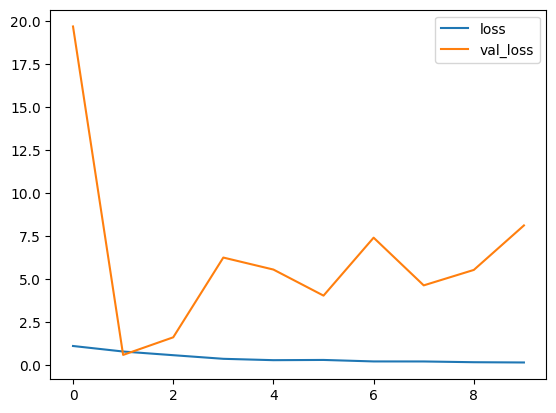

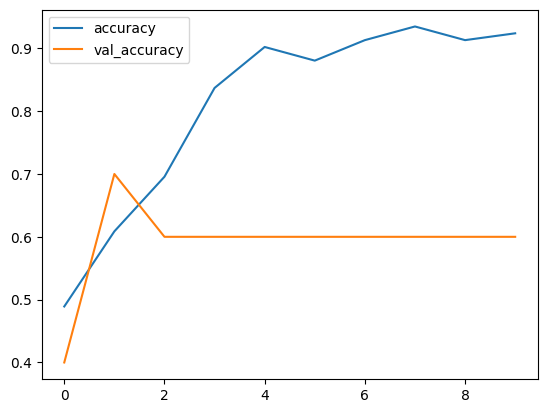

In [7]:
# Model Evaluation 
# Let’s visualize the training and validation accuracy with each epoch. 
# • history_df = pd.DataFrame(history.history) converts the training history into a DataFrame. 
# • history_df.loc[:, ['loss', 'val_loss']].plot() plots the training and validation loss. 
# • history_df.loc[:, ['accuracy', 'val_accuracy']].plot() plots the training and validation accuracy. 

history_df = pd.DataFrame(history.history) 
history_df.loc[:, ['loss', 'val_loss']].plot() 
history_df.loc[:, ['accuracy', 'val_accuracy']].plot() 
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


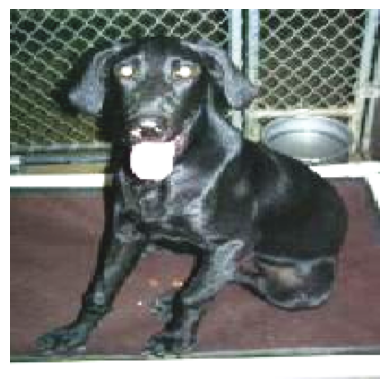

In [9]:
# Model Testing and Prediction 
# Let's check the model for random images. 
# • img = image.load_img(image_path, target_size=(200, 200)) loads the image and resizes it to 
# 200x200 pixels. 
# • plt.imshow(img) displays the image. 
# • img = image.img_to_array(img) converts the image to a NumPy array. 
# • img = np.expand_dims(img, axis=0) adds an extra dimension for batch processing. 
# • result = model.predict(img) makes a prediction using the model.
from tensorflow.keras.preprocessing import image 
import numpy as np 
import matplotlib.pyplot as plt 
def predict_image(image_path): 
    img = image.load_img(image_path, target_size=(200, 200)) 
    plt.imshow(img) 
    plt.axis('off') 
    img = image.img_to_array(img) 
    img = np.expand_dims(img, axis=0) 
    img = img / 255.0   # IMPORTANT 
    result = model.predict(img) 
    score = result[0][0]
    
#CORRECT LABEL MAPPING 
    if score >= 0.4: 
        label = "Dog"
    else: 
        label = "Cat" 
        plt.title(f"{label} ({score:.4f})") 
        plt.show() 
        print(f"Image: {image_path}") 
        print(f"Prediction Score: {score:.4f}") 
        print(f"Predicted Label: {label}")
        print("-"*30) 

# Test 
predict_image('dog-vs-cat/cat/50.jpg') 
predict_image('dog-vs-cat/dog/50.jpg')